In [3]:
# ============================================================================
# COMPLETE TRAINING AND PREDICTION PIPELINE FOR TELECOM CHURN
# ============================================================================
import pandas as pd
import numpy as np
import re
from datetime import datetime
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, f1_score
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import VotingClassifier
import warnings
warnings.filterwarnings('ignore')
# ============================================================================
# HELPER FUNCTIONS
# ============================================================================
def clean_feature_names(columns):
    """Clean feature names to remove special characters for LightGBM compatibility"""
    cleaned = []
    for col in columns:
        cleaned_name = re.sub(r'[^A-Za-z0-9_]', '_', str(col))
        cleaned_name = re.sub(r'_+', '_', cleaned_name)
        cleaned_name = cleaned_name.strip('_')
        cleaned.append(cleaned_name)
    return cleaned
def create_features(df, is_train=True):
    """
    Create features from the telecom dataset
    """
    data = df.copy()
    
    # 1. ARPU and billing features
    data['arpu_per_year'] = data['arpu'] / 12
    data['avg_bill_per_mou'] = data['l3m_avg_bill_dura'] / (data['l3m_avg_mou'] + 1)
    data['bill_usage_ratio'] = data['cm_tot_bill_dura'] / (data['l3m_avg_bill_dura'] + 1)
    
    # 2. Data usage features
    data['flux_usage_ratio'] = data['cm_flux_use'] / (data['cm_base_plan_flux'] + data['cm_chos_plan_flux'] + 1)
    data['4g_usage_ratio'] = data['flux_4g_use'] / (data['cm_flux_use'] + 1)
    data['upload_download_ratio'] = data['flux_up_4g_sum'] / (data['flux_down_4g_sum'] + 1)
    data['avg_daily_flux'] = data['cm_flux_use'] / (data['gprs_days'] + 1)
    
    # 3. Time-based usage patterns
    data['wday_flux_total'] = data['wday_day_flux'] + data['wday_night_flux']
    data['nwday_flux_total'] = data['nwday_day_flux'] + data['nwday_night_flux']
    data['wday_vs_nwday'] = data['wday_flux_total'] / (data['nwday_flux_total'] + 1)
    data['day_vs_night_wday'] = data['wday_day_flux'] / (data['wday_night_flux'] + 1)
    data['day_vs_night_nwday'] = data['nwday_day_flux'] / (data['nwday_night_flux'] + 1)
    
    # 4. Over-plan usage
    data['has_over_plan'] = (data['cm_over_plan_flux'] > 0).astype(int)
    data['over_plan_ratio'] = data['cm_over_plan_flux'] / (data['cm_base_plan_flux'] + data['cm_chos_plan_flux'] + 1)
    
    # 5. Voice usage features
    data['local_voice_ratio'] = data['cm_local_voice_dura'] / (data['cm_tot_bill_dura'] + 1)
    data['voice_data_ratio'] = data['cm_tot_bill_dura'] / (data['cm_flux_use'] + 1)
    
    # 6. Broadband features
    if 'bd_flux_m' in data.columns:
        data['has_broadband'] = (data['bd_flux_m'] > 0).astype(int)
        data['bd_usage_intensity'] = data['bd_flux_m'] / (data['bd_dur_m'] + 1)
        data['bd_avg_session_dur'] = data['bd_dur_m'] / (data['bd_cnt_m'] + 1)
        data['mobile_bd_ratio'] = data['cm_flux_use'] / (data['bd_flux_m'] + 1)
    
    # 7. TV and entertainment features
    if 'user_duration_m' in data.columns:
        data['tv_engagement'] = data['user_duration_m'] / (data['login_times_m'] + 1)
        data['click_watch_ratio'] = data['click_times_m'] / (data['watch_times_m'] + 1)
        data['active_days_ratio'] = data['open_day_m'] / 30
    
    # 8. Video usage features
    video_cols = ['gm_use_dur', 'shrt_vid_use_dur', 'long_vid_use_dur', 
                  'anchor_use_dur', 'wtch_liv_use_dur', 'netdisk_use_dur']
    if all(col in data.columns for col in video_cols):
        data['total_video_dur'] = data[video_cols].sum(axis=1)
        data['game_video_ratio'] = data['gm_use_dur'] / (data['total_video_dur'] + 1)
        data['short_long_ratio'] = data['shrt_vid_use_dur'] / (data['long_vid_use_dur'] + 1)
        
        # Day vs night patterns
        data['game_day_ratio'] = data['gm_dayt_use_dur'] / (data['gm_use_dur'] + 1)
        data['video_night_usage'] = (data['shrt_vid_ngt_use_dur'] + 
                                      data['long_vid_ngt_use_dur'] + 
                                      data['anchor_ngt_use_dur'])
        data['video_day_usage'] = (data['shrt_vid_dayt_use_dur'] + 
                                    data['long_vid_dayt_use_dur'] + 
                                    data['anchor_dayt_use_dur'])
        data['video_day_night_ratio'] = data['video_day_usage'] / (data['video_night_usage'] + 1)
    
    # 9. Content consumption features
    content_cols = ['video_cnt_m', 'read_cnt_m', 'music_cnt_m', 'caijing_cnt_m', 
                    'travel_cnt_m', 'game_cnt_m', 'edu_cnt_m']
    if all(col in data.columns for col in content_cols):
        data['total_content_cnt'] = data[content_cols].sum(axis=1)
        data['content_diversity'] = (data[content_cols] > 0).sum(axis=1)
        data['avg_read_time'] = data['read_time_m'] / (data['read_cnt_m'] + 1)
        data['edu_engagement'] = data['edu_time_m'] / (data['edu_cnt_m'] + 1)
    
    # 10. User labels aggregation
    label_cols = ['hi_flux_usr_lbl', 'sev_vid_usr_lbl', 'liv_usr_lbl', 
                  'netdisk_usr_lbl', 'vid_usr_lbl', 'read_usr_lbl', 
                  'gm_usr_lbl', 'msc_usr_lbl']
    if all(col in data.columns for col in label_cols):
        data['total_user_labels'] = data[label_cols].sum(axis=1)
        data['is_heavy_user'] = (data['total_user_labels'] > 3).astype(int)
        data['is_video_focused'] = ((data['vid_usr_lbl'] + data['sev_vid_usr_lbl']) > 1).astype(int)
    
    # 11. Network and service features
    data['is_premium_user'] = ((data['is_fam_vnet_user'] == 1) | 
                               (data['is_ent_vnet_user'] == 1)).astype(int)
    data['has_unlimited'] = data['if_nulim_prod']
    data['service_stability'] = 1 - data['is_bd_status_abnormal']
    
    # 12. Loyalty and tenure features
    data['tenure_years'] = data['innet_dura'] / 365
    data['is_long_term'] = (data['innet_dura'] > 1095).astype(int)  # > 3 years
    data['contract_value'] = data['term_cont_mon'] * data['term_cont_dfee']
    
    # 13. Age-based features
    data['age_group'] = pd.cut(data['age'], bins=[0, 25, 35, 45, 55, 100], 
                                labels=['young', 'young_adult', 'middle', 'mature', 'senior'])
    data['is_young'] = (data['age'] < 30).astype(int)
    data['is_senior'] = (data['age'] > 55).astype(int)
    
    # 14. Out-of-network usage
    data['total_out_usage'] = data['out_gprs'] + data['out_call']
    data['out_usage_ratio'] = data['total_out_usage'] / (data['cm_flux_use'] + data['cm_tot_bill_dura'] + 1)
    
    # 15. Engagement scores
    data['engagement_score'] = (
        data['login_times_m'] * 0.2 + 
        data['click_times_m'] * 0.2 + 
        data['watch_times_m'] * 0.3 + 
        data['open_day_m'] * 0.3
    )
    
    # 16. Revenue metrics
    data['revenue_per_gb'] = data['arpu'] / ((data['cm_flux_use'] / 1024) + 1)
    data['revenue_per_minute'] = data['arpu'] / (data['l3m_avg_mou'] + 1)
    
    # Handle categorical features
    if 'age_group' in data.columns:
        data['age_group_encoded'] = LabelEncoder().fit_transform(data['age_group'].astype(str))
    
    return data
def get_feature_columns(df):
    """Get the list of feature columns to use for modeling"""
    exclude_cols = ['Unnamed: 0', 'id', 'label', 'age_group']
    feature_cols = [col for col in df.columns if col not in exclude_cols]
    return feature_cols
# ============================================================================
# LOAD AND PREPARE TRAINING DATA
# ============================================================================
print("=" * 80)
print("LOADING TRAINING DATA")
print("=" * 80)
df_train = pd.read_csv('./train.csv')
print(f"Training data shape: {df_train.shape}")
print(f"\nClass distribution:")
print(df_train['label'].value_counts())
print(f"Class ratio: {df_train['label'].value_counts()[0] / df_train['label'].value_counts()[1]:.2f}:1")
# Check for missing values
print(f"\nMissing values:")
missing_summary = df_train.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)
if len(missing_summary) > 0:
    print(missing_summary.head(10))
else:
    print("No missing values found")
# ============================================================================
# FEATURE ENGINEERING
# ============================================================================
print("\n" + "=" * 80)
print("CREATING FEATURES")
print("=" * 80)
df_train_processed = create_features(df_train, is_train=True)
# Get feature columns
feature_cols = get_feature_columns(df_train_processed)
print(f"Total features after engineering: {len(feature_cols)}")
# Clean feature names
original_feature_cols = feature_cols.copy()
cleaned_feature_cols = clean_feature_names(feature_cols)
feature_name_mapping = dict(zip(cleaned_feature_cols, original_feature_cols))
# Prepare X and y
X = df_train_processed[feature_cols].copy()
X.columns = cleaned_feature_cols
y = df_train_processed['label']
# Fill missing values
print("\nHandling missing values...")
# Use median for numeric, mode for categorical
for col in X.columns:
    if X[col].dtype in ['float64', 'int64']:
        X[col].fillna(X[col].median(), inplace=True)
    else:
        X[col].fillna(X[col].mode()[0] if len(X[col].mode()) > 0 else 0, inplace=True)
# Replace infinities
X.replace([np.inf, -np.inf], 0, inplace=True)
print(f"Final feature matrix shape: {X.shape}")

LOADING TRAINING DATA
Training data shape: (59904, 88)

Class distribution:
label
0    44904
1    15000
Name: count, dtype: int64
Class ratio: 2.99:1

Missing values:
gm_use_dur               47451
gm_dayt_use_dur          47451
gm_ngt_use_dur           47451
shrt_vid_use_dur         47451
shrt_vid_dayt_use_dur    47451
shrt_vid_ngt_use_dur     47451
long_vid_use_dur         47451
long_vid_dayt_use_dur    47451
long_vid_ngt_use_dur     47451
anchor_use_dur           47451
dtype: int64

CREATING FEATURES
Total features after engineering: 136

Handling missing values...
Final feature matrix shape: (59904, 136)



TRAINING PYTORCH DEEP NEURAL NETWORK
Model Configuration:
  hidden_dims: [512, 256, 128]
  dropout_rate: 0.6
  learning_rate: 0.0005
  weight_decay: 0.002
  batch_size: 512
  epochs: 200
  early_stopping_patience: 50
  gradient_clip: 0.5
  resampling_strategy: smote_tomek
  loss_type: focal
  scheduler_type: cosine

Normalizing features...


Splitting data...
Training set shape: (47923, 136)
Test set shape: (11981, 136)
Training class distribution:
label
0    35923
1    12000
Name: count, dtype: int64
Test class distribution:
label
0    8981
1    3000
Name: count, dtype: int64
Using device: cuda
Original class distribution: [35923 12000]
Resampled class distribution: [35923 35721]

Dataset sizes - Original: 47923, Balanced: 71644
Starting optimized training...

Epoch 1/200
Train Loss: 1.0836 | Train Acc: 0.5513 | Val Loss: 0.2076 | Val Acc: 0.6580 | Val AUC: 0.7391 | Val F1: 0.5136 | LR: 0.000497

Epoch 2/200
Train Loss: 0.5925 | Train Acc: 0.5950 | Val Loss: 0.1311 | Val Acc: 0.7024 | Val AUC: 0.7505 | Val F1: 0.5304 | LR: 0.000488

Epoch 3/200
Train Loss: 0.3957 | Train Acc: 0.5941 | Val Loss: 0.0891 | Val Acc: 0.6765 | Val AUC: 0.7446 | Val F1: 0.5255 | LR: 0.000473

Epoch 4/200
Train Loss: 0.2571 | Train Acc: 0.5917 | Val Loss: 0.0599 | Val Acc: 0.6742 | Val AUC: 0.7446 | Val F1: 0.5196 | LR: 0.000452

Epoch 5/200
Trai

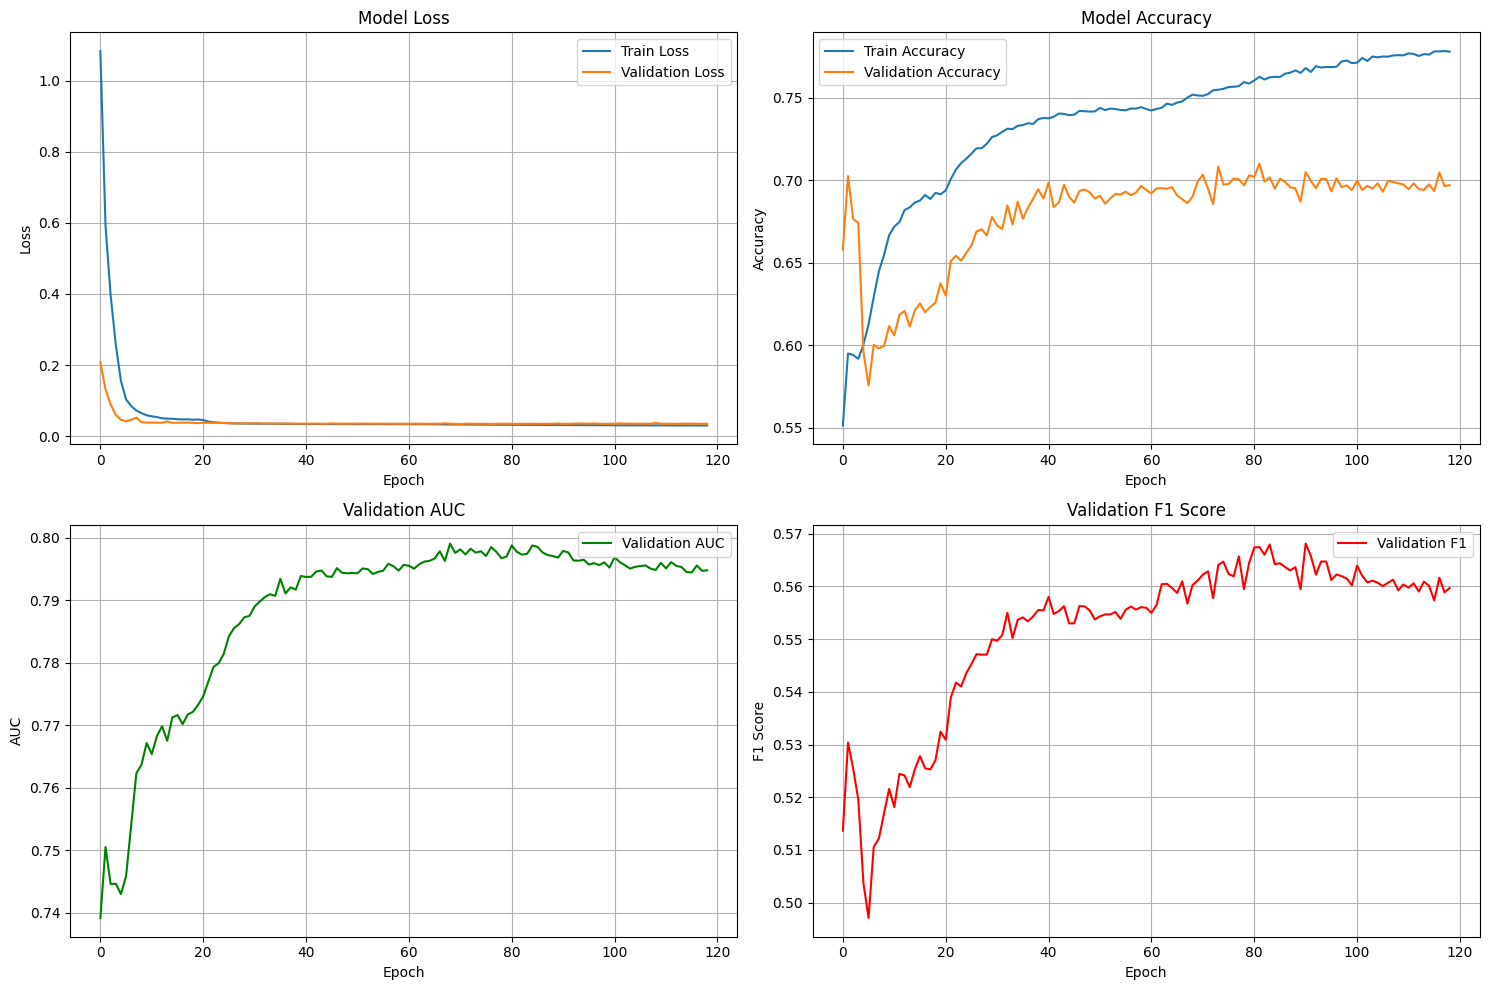


FINAL MODEL EVALUATION


Evaluating: 100%|██████████| 47/47 [00:00<00:00, 1203.17it/s]


Test Results:
Accuracy: 0.6969
AUC Score: 0.7948
F1 Score: 0.5597

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.67      0.77      8981
           1       0.44      0.77      0.56      3000

    accuracy                           0.70     11981
   macro avg       0.67      0.72      0.66     11981
weighted avg       0.78      0.70      0.72     11981



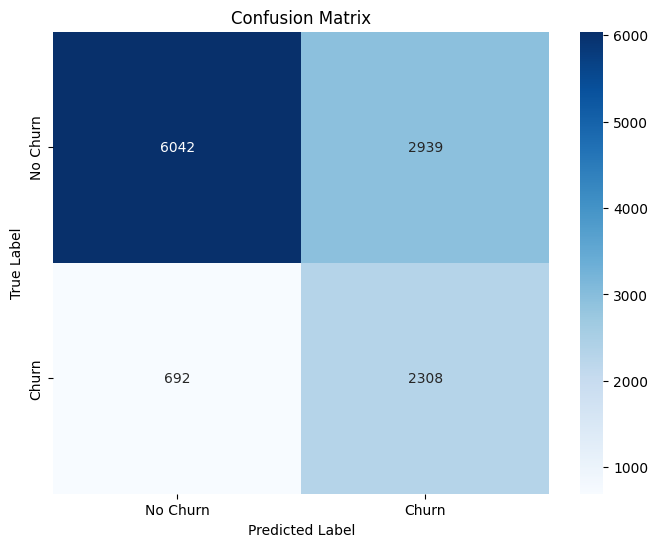


SAVING MODEL
Model saved as 'churn_classifier_pytorch.pth'

Training completed successfully!
Use the predict_churn() function to make predictions on new data.

SIMPLIFIED CROSS-VALIDATION (3-fold)

Fold 1/3
Using device: cuda
Original class distribution: [29936 10000]
Resampled class distribution: [29936 29750]

Dataset sizes - Original: 39936, Balanced: 59686
Starting optimized training...

Epoch 1/50
Train Loss: 0.9940 | Train Acc: 0.5479 | Val Loss: 0.2028 | Val Acc: 0.6763 | Val AUC: 0.7534 | Val F1: 0.5272 | LR: 0.000497

Epoch 2/50
Train Loss: 0.6528 | Train Acc: 0.5860 | Val Loss: 0.1515 | Val Acc: 0.6469 | Val AUC: 0.7592 | Val F1: 0.5242 | LR: 0.000488

Epoch 3/50
Train Loss: 0.3924 | Train Acc: 0.5996 | Val Loss: 0.0771 | Val Acc: 0.6077 | Val AUC: 0.7625 | Val F1: 0.5104 | LR: 0.000473

Epoch 4/50
Train Loss: 0.1894 | Train Acc: 0.6017 | Val Loss: 0.0441 | Val Acc: 0.5856 | Val AUC: 0.7542 | Val F1: 0.5006 | LR: 0.000452

Epoch 5/50
Train Loss: 0.0929 | Train Acc: 0.6003 | 

Evaluating: 100%|██████████| 78/78 [00:00<00:00, 1187.11it/s]


Test Results:
Accuracy: 0.6757
AUC Score: 0.8007
F1 Score: 0.5600

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.63      0.74     14968
           1       0.42      0.82      0.56      5000

    accuracy                           0.68     19968
   macro avg       0.67      0.73      0.65     19968
weighted avg       0.79      0.68      0.70     19968

Fold 1 Results - Accuracy: 0.6757, AUC: 0.8007, F1: 0.5600

Fold 2/3
Using device: cuda
Original class distribution: [29936 10000]


Resampled class distribution: [29936 29749]

Dataset sizes - Original: 39936, Balanced: 59685
Starting optimized training...

Epoch 1/50
Train Loss: 1.1677 | Train Acc: 0.5486 | Val Loss: 0.2577 | Val Acc: 0.6593 | Val AUC: 0.7416 | Val F1: 0.5187 | LR: 0.000497

Epoch 2/50
Train Loss: 0.7964 | Train Acc: 0.5882 | Val Loss: 0.2097 | Val Acc: 0.6305 | Val AUC: 0.7500 | Val F1: 0.5165 | LR: 0.000488

Epoch 3/50
Train Loss: 0.5572 | Train Acc: 0.5986 | Val Loss: 0.1229 | Val Acc: 0.6233 | Val AUC: 0.7447 | Val F1: 0.5082 | LR: 0.000473

Epoch 4/50
Train Loss: 0.3548 | Train Acc: 0.6062 | Val Loss: 0.0723 | Val Acc: 0.5927 | Val AUC: 0.7402 | Val F1: 0.4958 | LR: 0.000452

Epoch 5/50
Train Loss: 0.2187 | Train Acc: 0.6024 | Val Loss: 0.0537 | Val Acc: 0.5830 | Val AUC: 0.7319 | Val F1: 0.4895 | LR: 0.000427

Epoch 6/50
Train Loss: 0.1331 | Train Acc: 0.6045 | Val Loss: 0.0420 | Val Acc: 0.5794 | Val AUC: 0.7309 | Val F1: 0.4835 | LR: 0.000397

Epoch 7/50
Train Loss: 0.0934 | Train Acc: 0.6

Evaluating: 100%|██████████| 78/78 [00:00<00:00, 1188.00it/s]


Test Results:
Accuracy: 0.6908
AUC Score: 0.7877
F1 Score: 0.5526

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.67      0.76     14968
           1       0.43      0.76      0.55      5000

    accuracy                           0.69     19968
   macro avg       0.66      0.71      0.66     19968
weighted avg       0.78      0.69      0.71     19968

Fold 2 Results - Accuracy: 0.6908, AUC: 0.7877, F1: 0.5526

Fold 3/3
Using device: cuda
Original class distribution: [29936 10000]


Resampled class distribution: [29936 29758]

Dataset sizes - Original: 39936, Balanced: 59694
Starting optimized training...

Epoch 1/50
Train Loss: 1.0564 | Train Acc: 0.5606 | Val Loss: 0.2593 | Val Acc: 0.6185 | Val AUC: 0.7558 | Val F1: 0.5168 | LR: 0.000497

Epoch 2/50
Train Loss: 0.6940 | Train Acc: 0.5974 | Val Loss: 0.1969 | Val Acc: 0.5973 | Val AUC: 0.7599 | Val F1: 0.5170 | LR: 0.000488

Epoch 3/50
Train Loss: 0.4921 | Train Acc: 0.6071 | Val Loss: 0.1123 | Val Acc: 0.5903 | Val AUC: 0.7523 | Val F1: 0.5100 | LR: 0.000473

Epoch 4/50
Train Loss: 0.3208 | Train Acc: 0.6135 | Val Loss: 0.0745 | Val Acc: 0.5657 | Val AUC: 0.7563 | Val F1: 0.5039 | LR: 0.000452

Epoch 5/50
Train Loss: 0.2116 | Train Acc: 0.6172 | Val Loss: 0.0576 | Val Acc: 0.5303 | Val AUC: 0.7368 | Val F1: 0.4854 | LR: 0.000427

Epoch 6/50
Train Loss: 0.1406 | Train Acc: 0.6196 | Val Loss: 0.0511 | Val Acc: 0.5290 | Val AUC: 0.7270 | Val F1: 0.4879 | LR: 0.000397

Epoch 7/50
Train Loss: 0.1088 | Train Acc: 0.6

Evaluating: 100%|██████████| 78/78 [00:00<00:00, 1194.93it/s]


Test Results:
Accuracy: 0.5565
AUC Score: 0.7597
F1 Score: 0.4994

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.45      0.60     14968
           1       0.35      0.88      0.50      5000

    accuracy                           0.56     19968
   macro avg       0.63      0.67      0.55     19968
weighted avg       0.78      0.56      0.58     19968

Fold 3 Results - Accuracy: 0.5565, AUC: 0.7597, F1: 0.4994

Cross-Validation Results (Mean ± Std):
Accuracy: 0.6410 ± 0.0601
AUC:      0.7827 ± 0.0171
F1:       0.5373 ± 0.0270


In [4]:
# ============================================================================
# PYTORCH DEEP NEURAL NETWORK FOR TELECOM CHURN CLASSIFICATION (FIXED)
# ============================================================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# ============================================================================
# DATASET CLASS
# ============================================================================
class ChurnDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X.values if hasattr(X, 'values') else X)
        self.y = torch.LongTensor(y.values if hasattr(y, 'values') else y)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ============================================================================
# NEURAL NETWORK ARCHITECTURE
# ============================================================================
class ChurnClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims=[512, 256, 128, 64], dropout_rate=0.3):
        super(ChurnClassifier, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        # Input layer with batch normalization
        layers.append(nn.BatchNorm1d(input_dim))
        
        # Hidden layers
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ])
            prev_dim = hidden_dim
        
        # Output layer
        layers.append(nn.Linear(prev_dim, 2))
        
        self.network = nn.Sequential(*layers)
        
        # Initialize weights
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        return self.network(x)

# ============================================================================
# TRAINING FUNCTIONS (FIXED)
# ============================================================================
def create_weighted_sampler(y):
    """Create weighted sampler for imbalanced dataset - FIXED VERSION"""
    # Convert to numpy array if it's a pandas Series
    if hasattr(y, 'values'):
        y_array = y.values
    else:
        y_array = np.array(y)
    
    # Get unique classes and their counts
    unique_classes, class_counts = np.unique(y_array, return_counts=True)
    
    # Calculate class weights (inverse frequency)
    class_weights = 1.0 / class_counts
    
    # Create sample weights for each sample
    sample_weights = np.zeros(len(y_array))
    for i, class_label in enumerate(unique_classes):
        mask = y_array == class_label
        sample_weights[mask] = class_weights[i]
    
    # Convert to torch tensor
    sample_weights = torch.FloatTensor(sample_weights)
    
    return WeightedRandomSampler(sample_weights, len(sample_weights))

def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    progress_bar = tqdm(train_loader, desc="Training", leave=False)
    
    for batch_x, batch_y in progress_bar:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
        
        # Update progress bar
        progress_bar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{100 * correct / total:.2f}%'
        })
    
    return total_loss / len(train_loader), correct / total

def validate_epoch(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        progress_bar = tqdm(val_loader, desc="Validating", leave=False)
        
        for batch_x, batch_y in progress_bar:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            
            total_loss += loss.item()
            
            probs = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs.data, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())  # Probability of class 1
    
    return total_loss / len(val_loader), all_preds, all_labels, all_probs

from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from sklearn.preprocessing import StandardScaler
import torch.nn.utils as utils

def train_model_optimized(X_train, y_train, X_val, y_val, config):
    """Optimized training with SMOTE+Tomek and advanced techniques"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Data preprocessing and balancing
    X_train_balanced, y_train_balanced = preprocess_and_balance_data(
        X_train, y_train, config.get('resampling_strategy', 'smote_tomek')
    )
    
    # Create datasets
    train_dataset = ChurnDataset(X_train_balanced, y_train_balanced)
    val_dataset = ChurnDataset(X_val, y_val)
    
    # Create data loaders - No weighted sampling needed with balanced data
    train_loader = DataLoader(
        train_dataset, 
        batch_size=config['batch_size'], 
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )
    val_loader = DataLoader(
        val_dataset, 
        batch_size=config['batch_size'], 
        shuffle=False, 
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )
    
    # Initialize model with improved architecture
    model = ChurnClassifierImproved(
        input_dim=X_train_balanced.shape[1],
        hidden_dims=config['hidden_dims'],
        dropout_rate=config['dropout_rate']
    ).to(device)
    
    # Loss function - Focal Loss for better handling of hard examples
    criterion = get_loss_function(config.get('loss_type', 'focal'))
    
    # Optimizer with improved settings
    optimizer = optim.AdamW(
        model.parameters(), 
        lr=config['learning_rate'], 
        weight_decay=config['weight_decay'],
        betas=(0.9, 0.999),
        eps=1e-8
    )
    
    # Advanced learning rate scheduling
    scheduler = get_scheduler(optimizer, config)
    
    # Training history
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'val_auc': [], 'val_f1': [],
        'learning_rates': []
    }
    
    best_val_auc = 0
    best_model_state = None
    patience_counter = 0
    
    print(f"\nDataset sizes - Original: {len(X_train)}, Balanced: {len(X_train_balanced)}")
    print("Starting optimized training...")
    
    for epoch in range(config['epochs']):
        print(f"\nEpoch {epoch+1}/{config['epochs']}")
        
        # Training with gradient clipping
        train_loss, train_acc = train_epoch_optimized(
            model, train_loader, criterion, optimizer, device, config
        )
        
        # Validation
        val_loss, val_preds, val_labels, val_probs = validate_epoch_optimized(
            model, val_loader, criterion, device
        )
        
        # Calculate metrics
        val_acc = (np.array(val_preds) == np.array(val_labels)).mean()
        val_auc = roc_auc_score(val_labels, val_probs)
        val_f1 = f1_score(val_labels, val_preds)
        
        # Update learning rate
        if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        else:
            scheduler.step()
        
        current_lr = optimizer.param_groups[0]['lr']
        
        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)
        history['val_f1'].append(val_f1)
        history['learning_rates'].append(current_lr)
        
        # Early stopping and best model tracking
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        # Print progress
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
              f"Val AUC: {val_auc:.4f} | Val F1: {val_f1:.4f} | LR: {current_lr:.6f}")
        
        # Early stopping
        if patience_counter >= config['early_stopping_patience']:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break
        
        # Stop if learning rate becomes too small
        if current_lr < 1e-7:
            print(f"\nStopping due to very small learning rate: {current_lr}")
            break
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\nLoaded best model with validation AUC: {best_val_auc:.4f}")
    
    return model, history

def preprocess_and_balance_data(X_train, y_train, strategy='smote_tomek'):
    """Preprocess and balance training data"""
    print(f"Original class distribution: {np.bincount(y_train)}")
    
    if strategy == 'smote_tomek':
        # SMOTE + Tomek Links combination
        smote_tomek = SMOTETomek(
            smote=SMOTE(random_state=42, k_neighbors=3),
            tomek=TomekLinks(),
            random_state=42
        )
        X_resampled, y_resampled = smote_tomek.fit_resample(X_train, y_train)
        
    elif strategy == 'smote':
        # SMOTE only
        smote = SMOTE(random_state=42, k_neighbors=3)
        X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
        
    elif strategy == 'tomek':
        # Tomek Links only (undersampling)
        tomek = TomekLinks()
        X_resampled, y_resampled = tomek.fit_resample(X_train, y_train)
        
    else:
        # No resampling
        X_resampled, y_resampled = X_train, y_train
    
    print(f"Resampled class distribution: {np.bincount(y_resampled)}")
    return X_resampled, y_resampled

def get_loss_function(loss_type='focal'):
    """Get optimized loss function"""
    if loss_type == 'focal':
        return FocalLoss(alpha=0.25, gamma=2.0)
    elif loss_type == 'weighted_ce':
        return nn.CrossEntropyLoss(weight=torch.tensor([0.3, 0.7]))
    else:
        return nn.CrossEntropyLoss()

class FocalLoss(nn.Module):
    """Focal Loss for handling class imbalance"""
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        
    def forward(self, inputs, targets):
        ce_loss = nn.CrossEntropyLoss(reduction='none')(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

def get_scheduler(optimizer, config):
    """Get learning rate scheduler"""
    scheduler_type = config.get('scheduler_type', 'plateau')
    
    if scheduler_type == 'cosine':
        return optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=20, T_mult=2
        )
    elif scheduler_type == 'step':
        return optim.lr_scheduler.StepLR(
            optimizer, step_size=30, gamma=0.5
        )
    else:  # plateau
        return optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=10, 
            # verbose=True
        )

def train_epoch_optimized(model, train_loader, criterion, optimizer, device, config):
    """Optimized training epoch with gradient clipping"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device, non_blocking=True), target.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        
        # Gradient clipping
        if config.get('gradient_clip'):
            utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
    
    return total_loss / len(train_loader), correct / total

def validate_epoch_optimized(model, val_loader, criterion, device):
    """Optimized validation epoch"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device, non_blocking=True), target.to(device, non_blocking=True)
            output = model(data)
            loss = criterion(output, target)
            
            total_loss += loss.item()
            
            # Get predictions and probabilities
            probs = torch.softmax(output, dim=1)
            _, preds = torch.max(output, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(target.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())  # Probability of positive class
    
    return total_loss / len(val_loader), all_preds, all_labels, all_probs

# Improved model architecture
class ChurnClassifierImproved(nn.Module):
    def __init__(self, input_dim, hidden_dims=[512, 256, 128, 64], dropout_rate=0.3):
        super(ChurnClassifierImproved, self).__init__()
        
        self.input_bn = nn.BatchNorm1d(input_dim)
        self.layers = nn.ModuleList()
        
        prev_dim = input_dim
        for i, hidden_dim in enumerate(hidden_dims):
            self.layers.append(nn.ModuleDict({
                'linear': nn.Linear(prev_dim, hidden_dim),
                'bn': nn.BatchNorm1d(hidden_dim),
                'dropout': nn.Dropout(dropout_rate)
            }))
            prev_dim = hidden_dim
        
        self.output = nn.Linear(prev_dim, 2)
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        x = self.input_bn(x)
        
        for layer in self.layers:
            x = layer['linear'](x)
            x = layer['bn'](x)
            x = torch.relu(x)
            x = layer['dropout'](x)
        
        return self.output(x)

# ============================================================================
# EVALUATION FUNCTIONS
# ============================================================================
def evaluate_model(model, X_test, y_test, device):
    """Evaluate the trained model"""
    model.eval()
    test_dataset = ChurnDataset(X_test, y_test)
    test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)
    
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for batch_x, batch_y in tqdm(test_loader, desc="Evaluating"):
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            probs = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
    
    # Calculate metrics
    accuracy = (np.array(all_preds) == np.array(all_labels)).mean()
    auc_score = roc_auc_score(all_labels, all_probs)
    f1 = f1_score(all_labels, all_preds)
    
    print(f"\nTest Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"AUC Score: {auc_score:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    print(f"\nClassification Report:")
    print(classification_report(all_labels, all_preds))
    
    return all_preds, all_labels, all_probs

def plot_training_history(history):
    """Plot training history"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss
    axes[0, 0].plot(history['train_loss'], label='Train Loss')
    axes[0, 0].plot(history['val_loss'], label='Validation Loss')
    axes[0, 0].set_title('Model Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Accuracy
    axes[0, 1].plot(history['train_acc'], label='Train Accuracy')
    axes[0, 1].plot(history['val_acc'], label='Validation Accuracy')
    axes[0, 1].set_title('Model Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # AUC
    axes[1, 0].plot(history['val_auc'], label='Validation AUC', color='green')
    axes[1, 0].set_title('Validation AUC')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('AUC')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    # F1 Score
    axes[1, 1].plot(history['val_f1'], label='Validation F1', color='red')
    axes[1, 1].set_title('Validation F1 Score')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('F1 Score')
    axes[1, 1].legend()
    axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# ============================================================================
# MAIN TRAINING PIPELINE
# ============================================================================
print("\n" + "=" * 80)
print("TRAINING PYTORCH DEEP NEURAL NETWORK")
print("=" * 80)

# Model configuration
final_config = {
    'hidden_dims': [512, 256, 128],  # Reduce complexity further
    'dropout_rate': 0.6,  # Increase dropout
    'learning_rate': 0.0005,  # Lower learning rate
    'weight_decay': 0.002,  # Stronger regularization
    'batch_size': 512,  # Larger batch size
    'epochs': 200,
    'early_stopping_patience': 50,
    'gradient_clip': 0.5,  # Reduce gradient clipping
    'resampling_strategy': 'smote_tomek',
    'loss_type': 'focal',
    'scheduler_type': 'cosine'
}

print(f"Model Configuration:")
for key, value in final_config.items():
    print(f"  {key}: {value}")

# Normalize features
print("\nNormalizing features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Split data
print("Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Training class distribution:")
print(y_train.value_counts())
print(f"Test class distribution:")
print(y_test.value_counts())

# Train model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model, history = train_model_optimized(X_train, y_train, X_test, y_test, final_config)

# Plot training history
plot_training_history(history)

# Evaluate model
print("\n" + "=" * 80)
print("FINAL MODEL EVALUATION")
print("=" * 80)

test_preds, test_labels, test_probs = evaluate_model(model, X_test, y_test, device)

# Plot confusion matrix
plot_confusion_matrix(test_labels, test_preds)

# ============================================================================
# SAVE MODEL
# ============================================================================
print("\n" + "=" * 80)
print("SAVING MODEL")
print("=" * 80)

# Save model and scaler
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': final_config,
    'scaler': scaler,
    'feature_columns': X.columns.tolist(),
    'input_dim': X.shape[1]
}, 'churn_classifier_pytorch.pth')

print("Model saved as 'churn_classifier_pytorch.pth'")

# ============================================================================
# PREDICTION FUNCTION FOR NEW DATA
# ============================================================================
def predict_churn(model_path, X_new):
    """
    Load trained model and make predictions on new data
    
    Parameters:
    model_path: Path to saved model
    X_new: New data to predict (DataFrame)
    
    Returns:
    predictions: Binary predictions (0/1)
    probabilities: Probability of churn
    """
    # Load model and components
    checkpoint = torch.load(model_path, map_location='cpu')
    
    # Recreate model
    model = ChurnClassifier(
        input_dim=checkpoint['input_dim'],
        hidden_dims=checkpoint['model_config']['hidden_dims'],
        dropout_rate=checkpoint['model_config']['dropout_rate']
    )
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    # Scale features
    scaler = checkpoint['scaler']
    X_scaled = scaler.transform(X_new[checkpoint['feature_columns']])
    
    # Make predictions
    with torch.no_grad():
        X_tensor = torch.FloatTensor(X_scaled)
        outputs = model(X_tensor)
        probs = F.softmax(outputs, dim=1)
        predictions = torch.argmax(outputs, dim=1)
    
    return predictions.numpy(), probs[:, 1].numpy()

print("\nTraining completed successfully!")
print("Use the predict_churn() function to make predictions on new data.")

# Optional: Simplified cross-validation (comment out if you want to skip)
print("\n" + "=" * 80)
print("SIMPLIFIED CROSS-VALIDATION (3-fold)")
print("=" * 80)

def simple_cross_validate(X, y, config, n_splits=3):
    """Perform simplified cross-validation"""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    cv_scores = {'accuracy': [], 'auc': [], 'f1': []}
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"\nFold {fold + 1}/{n_splits}")
        
        X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
        y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
        
        # Reduced config for CV
        cv_config = config.copy()
        cv_config['epochs'] = 50
        cv_config['early_stopping_patience'] = 10
        
        # Train model for this fold
        fold_model, _ = train_model_optimized(X_train_cv, y_train_cv, X_val_cv, y_val_cv, cv_config)
        
        # Evaluate
        val_preds, val_labels, val_probs = evaluate_model(fold_model, X_val_cv, y_val_cv, device)
        
        # Calculate metrics
        accuracy = (np.array(val_preds) == np.array(val_labels)).mean()
        auc_score = roc_auc_score(val_labels, val_probs)
        f1 = f1_score(val_labels, val_preds)
        
        cv_scores['accuracy'].append(accuracy)
        cv_scores['auc'].append(auc_score)
        cv_scores['f1'].append(f1)
        
        print(f"Fold {fold + 1} Results - Accuracy: {accuracy:.4f}, AUC: {auc_score:.4f}, F1: {f1:.4f}")
    
    # Print CV results
    print(f"\nCross-Validation Results (Mean ± Std):")
    print(f"Accuracy: {np.mean(cv_scores['accuracy']):.4f} ± {np.std(cv_scores['accuracy']):.4f}")
    print(f"AUC:      {np.mean(cv_scores['auc']):.4f} ± {np.std(cv_scores['auc']):.4f}")
    print(f"F1:       {np.mean(cv_scores['f1']):.4f} ± {np.std(cv_scores['f1']):.4f}")
    
    return cv_scores

# Run simplified CV
cv_scores = simple_cross_validate(X_scaled, y, final_config, n_splits=3)